In [1]:
import numpy as np
import pandas as pd

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    RepeatVector,
    TimeDistributed,
    Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler

In [2]:
if devices := tf.config.list_physical_devices("GPU"):
    print(f"Running on {devices}")
else:
    print("Running on CPU")

Running on [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# load API key
try:
    from google.colab import userdata
    IN_COLAB = True
except:
    IN_COLAB = False


if IN_COLAB:
    !pip install -q zarr xarray fsspec aiohttp earthkit
    cdsapi_key = userdata.get("CDS-API-KEY")
else:
    import os

    %load_ext dotenv
    %dotenv

    cdsapi_key = os.getenv("CDS-API-KEY")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 99.9 MB/s eta 0:00:00


In [4]:
# load dataset

import xarray as xr

# Geo-chunked surface levels data (optimised for time-series at a single location)
geochunked_sfc_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-002/arco/reanalysis_era5_single_levels/sfc/geoChunked.zarr"

# Open the zarr store with xarray, users must insert their API key where indicated.
ds = xr.open_zarr(
    geochunked_sfc_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)

# only use data from Frankfurt am Main
ds = ds.sel(latitude=50.7, longitude=8.41, method="nearest")
ds = ds.sel(time=slice("2020-01-01", None))

# select variables
# TODO: select features that mean something, I don't need all, longer timeframe is better. Don't use
variables = ["t2m", "blh"]
ds = ds[variables]

# Inspect the variables
ds.load()
ds

<xarray.Dataset> Size: 913kB
Dimensions:    (time: 57072)
Coordinates:
  * time       (time) datetime64[ns] 457kB 2020-01-01 ... 2026-07-05T23:00:00
    latitude   float64 8B 50.75
    longitude  float64 8B 8.5
Data variables:
    t2m        (time) float32 228kB 270.5 271.2 270.8 ... 290.3 289.2 288.6
    blh        (time) float32 228kB 75.56 71.96 74.41 ... 694.2 504.1 522.2
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [5]:
ds.isnull().sum()

<xarray.Dataset> Size: 32B
Dimensions:    ()
Coordinates:
    latitude   float64 8B 50.75
    longitude  float64 8B 8.5
Data variables:
    t2m        int64 8B 0
    blh        int64 8B 0
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [6]:
# plot raw example data

from earthkit import plots as ekp
from earthkit import transforms as ekt

import warnings
warnings.filterwarnings(
    "ignore",
    message="TimeSeries is an experimental new feature*"
)

# Select variable to plot
variable_name = "t2m"
time = slice("2016-07-01", "2026-07-1")

plot_data_hourly = ds[variable_name].sel(time=time) - 273.15 # transform from Kelvin to Celsius
plot_data_monthly = ekt.temporal.monthly_mean(plot_data_hourly)

chart = ekp.TimeSeries()

chart.line(plot_data_hourly, label="Hourly")
chart.line(plot_data_monthly, label="Monthly mean")

chart.title("2m Temperature at Frankfurt am Main")
chart.legend()

chart.show()

ModuleNotFoundError: No module named 'earthkit'

In [7]:
# preprocess dataset
data = ds.to_dataarray(dim="features").transpose().values
scaler = StandardScaler()

data_scaled = scaler.fit_transform(data)
print(data)
print(data_scaled)

[[270.51862   75.55751 ]
 [271.17578   71.96151 ]
 [270.75494   74.406555]
 ...
 [290.2536   694.16235 ]
 [289.2387   504.07565 ]
 [288.60614  522.1506  ]]
[[-1.6729472  -1.0347532 ]
 [-1.5853611  -1.0423412 ]
 [-1.6414497  -1.0371819 ]
 ...
 [ 0.95730424  0.2705802 ]
 [ 0.8220408  -0.13052645]
 [ 0.73773295 -0.09238611]]


In [8]:
# build sequences
LOOKBACK = 72      # previous 72 hours
HORIZON = 24       # predict next 24 hours

def create_sequences(data, lookback, horizon):
    X = []
    y = []

    for i in range(len(data) - lookback - horizon):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback:i+lookback+horizon])

    return np.array(X), np.array(y)


X, y = create_sequences(
    data_scaled,
    LOOKBACK,
    HORIZON
)

print(X.shape)
print(y.shape)

(56976, 72, 2)
(56976, 24, 2)


In [9]:
# train/test split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [10]:
# define model
n_features = X.shape[2]

inputs = Input(shape=(LOOKBACK, n_features))

# Encoder
encoder = LSTM(
    128,
    activation="tanh"
)(inputs)

# Repeat context vector
decoder_input = RepeatVector(HORIZON)(encoder)

# Decoder
decoder = LSTM(
    128,
    activation="tanh",
    return_sequences=True
)(decoder_input)

outputs = TimeDistributed(
    Dense(n_features)
)(decoder)

model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 72, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 2)          │           258 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,914 (777.01 KB)

 Trainable params: 198,914 (777.01 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# compile model
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [12]:
print(np.isnan(X_train).any())
print(np.isnan(y_train).any())

print(np.max(X_train))
print(np.min(X_train))

False
False
4.9872537
-3.3979144


In [13]:
# train model

early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/100
570/570 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.4413 - mae: 0.4902 - val_loss: 0.4693 - val_mae: 0.5188
Epoch 2/100
570/570 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.3366 - mae: 0.4215 - val_loss: 0.4502 - val_mae: 0.5117
Epoch 3/100
570/570 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.3285 - mae: 0.4140 - val_loss: 0.4406 - val_mae: 0.5059
Epoch 4/100
570/570 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.3172 - mae: 0.4063 - val_loss: 0.4379 - val_mae: 0.5016
Epoch 5/100
570/570 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.3042 - mae: 0.3980 - val_loss: 0.3892 - val_mae: 0.4737
Epoch 6/100
570/570 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.2892 - mae: 0.3865 - val_loss: 0.3682 - val_mae: 0.4575
Epoch 7/100
570/570 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.2827 - mae: 0.3805 - val_loss: 0.3456 - val_mae: 0.4404
Epoch 8/100
570/570 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.2760 - mae: 0.3745 - val_loss: 0.3324 - val_mae: 0.4300
Epoch 9/100
570/570 ━━━━━━━━━━━━━━━━━

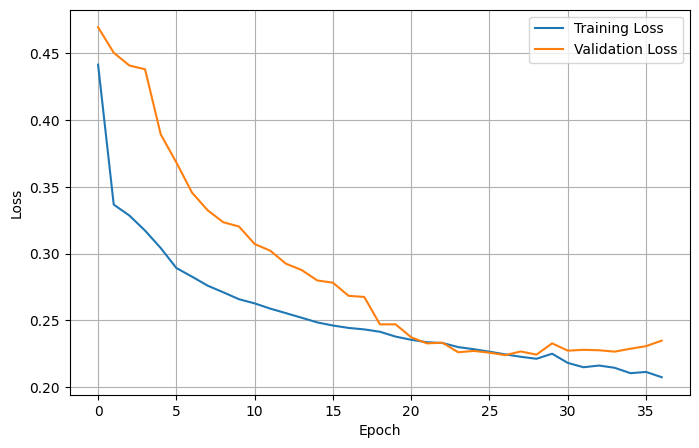

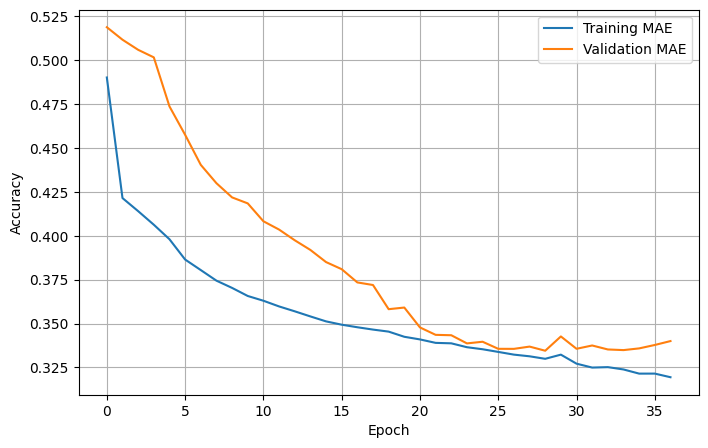

Keys: dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))


plt.plot(history.history["mae"], label="Training MAE")
if "val_mae" in history.history:
    plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


print("Keys:", history.history.keys())

In [14]:
# predict
pred = model.predict(X_test)

print(pred.shape)

357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
(11396, 24, 2)


In [15]:
# rescale features
pred_original = scaler.inverse_transform(
    pred.reshape(-1, n_features)
).reshape(pred.shape)

y_original = scaler.inverse_transform(
    y_test.reshape(-1, n_features)
).reshape(y_test.shape)